ejercicio 1

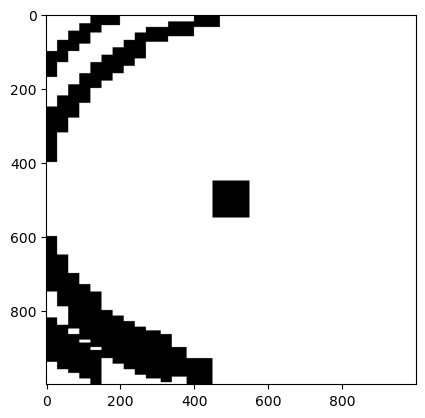

In [ ]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt



img = np.zeros((1000, 1000, 3), dtype=np.uint8)

img[:, :] = [255, 255, 255]

img[450:550, 450:550] = [0, 0, 0]


#primera curva arriba izq
img[100:170, 0:30] = [0, 0, 0]
img[70:130, 30:60] = [0, 0, 0]
img[45:100, 60:90] = [0, 0, 0]
img[25:80, 90:120] = [0, 0, 0]
img[0:50, 120:150] = [0, 0, 0]
img[0:30, 150:200] = [0, 0, 0]

#segunda curva izquierda
img[250:400, 0:30] = [0, 0, 0]
img[220:320, 30:60] = [0, 0, 0]
img[190:280, 60:90] = [0, 0, 0]
img[160:240, 90:120] = [0, 0, 0]
img[130:200, 120:150] = [0, 0, 0]
img[110:180, 150:180] = [0, 0, 0]
img[90:160, 180:210] = [0, 0, 0]
img[70:140, 210:240] = [0, 0, 0]
img[50:120, 240:270] = [0, 0, 0]
img[35:75, 270:330] = [0, 0, 0]
img[20:60, 330:400] = [0, 0, 0]
img[0:35, 400:470] = [0, 0, 0]



#tercera curva abajo izquierda
img[600:750, 0:30] = [0, 0, 0]
img[650:790, 30:60] = [0, 0, 0]
img[700:850, 60:90] = [0, 0, 0]
img[730:880, 90:120] = [0, 0, 0]
img[750:900, 120:150] = [0, 0, 0]
img[800:930, 150:180] = [0, 0, 0]
img[815:945, 180:210] = [0, 0, 0]
img[830:960, 210:240] = [0, 0, 0]
img[845:975, 240:270] = [0, 0, 0]
img[855:985, 270:310] = [0, 0, 0]
img[865:995, 310:340] = [0, 0, 0]
img[900:980, 340:380] = [0, 0, 0]
img[930:1000,380:450] = [0, 0, 0]



#cuarta curva abajo izquierda
img[820:940, 0:30] = [0, 0, 0]
img[840:960, 30:60] = [0, 0, 0]
img[865:970, 60:90] = [0, 0, 0]
img[888:985, 90:120] = [0, 0, 0]
img[908:1000, 120:150] = [0, 0, 0]


#inge se hizo lo que se pudo, las curvas de arriba estaban mucho mas faciles las de abajo ya mas dificiles
# por eso me perdi y perdi tiempo, porque las de arriba estaban re facil de hacer pero en si 
# es solo seguir haciendo asi e ir cambiando las coordenadas para acomodar cuadro a cuadro





plt.imshow(img)
plt.show()


Ejercicio 2

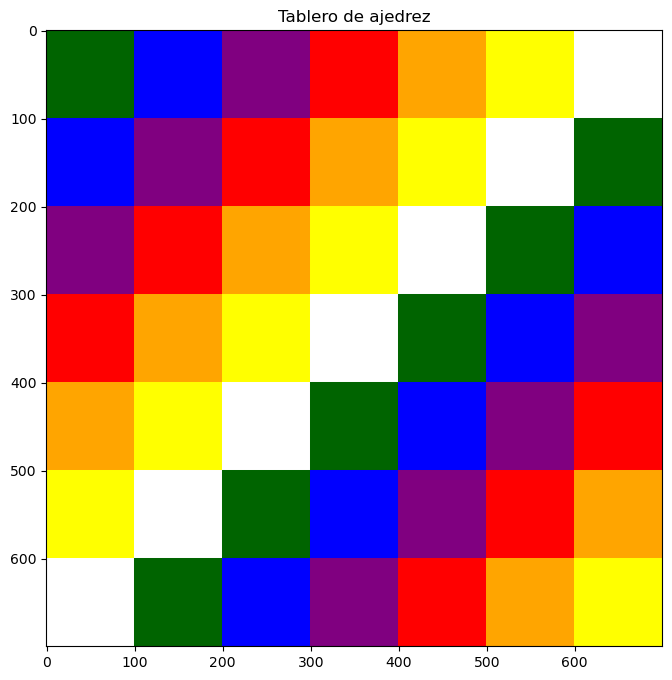

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np





size = 700
half = 100



R1 = np.ones((half, half)) * 0
G1 = np.ones((half, half)) * 100
B1 = np.ones((half, half)) * 0
bloq1 = np.dstack((R1, G1, B1))


R2 = np.ones((half, half)) * 0
G2 = np.ones((half, half)) * 0
B2 = np.ones((half, half)) * 255
bloq2 = np.dstack((R2, G2, B2))


R3 = np.ones((half, half)) * 128
G3 = np.ones((half, half)) * 0
B3 = np.ones((half, half)) * 128
bloq3 = np.dstack((R3, G3, B3))


R4 = np.ones((half, half)) * 255
G4 = np.ones((half, half)) * 0
B4 = np.ones((half, half)) * 0
bloq4 = np.dstack((R4, G4, B4))


R5 = np.ones((half, half)) * 255
G5 = np.ones((half, half)) * 165
B5 = np.ones((half, half)) * 0
bloq5 = np.dstack((R5, G5, B5))


R6 = np.ones((half, half)) * 255
G6 = np.ones((half, half)) * 255
B6 = np.ones((half, half)) * 0
bloq6 = np.dstack((R6, G6, B6))

G7 = np.ones((half, half)) * 255
R7 = np.ones((half, half)) * 255
B7 = np.ones((half, half)) * 255
bloq7 = np.dstack((R7, G7, B7))









bloques = [b.astype(np.uint8) for b in (bloq1, bloq2, bloq3, bloq4, bloq5, bloq6, bloq7)]

img = np.zeros((size, size, 3), dtype=np.uint8)

for row in range(7):
    for col in range(7):
        idx = (row + col) % 7
        y0 = row * half
        x0 = col * half
        img[y0:y0+half, x0:x0+half] = bloques[idx]


cv2.imwrite('imagenesGuardadas/cuadrantes_rgb.png', cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title('Tablero de ajedrez')
plt.savefig('imagenesGuardadas/tablero.png')
plt.show()

Ejercicio 3

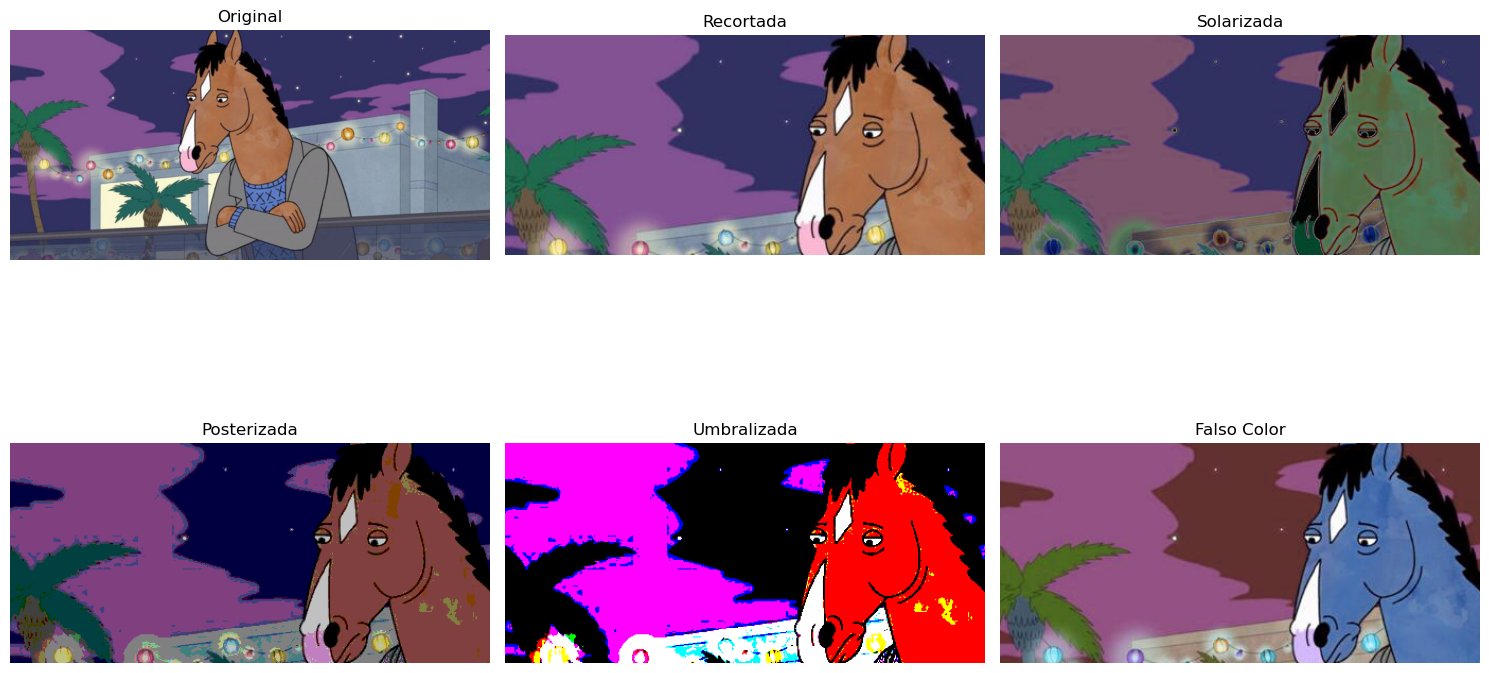

In [195]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('imagenesGuardadas', exist_ok=True)

def recortar_imagen_random(imagen):
    h, w = imagen.shape[:2]
    
 
    x1 = np.random.randint(0, w // 2)
    y1 = np.random.randint(0, h // 2)
    x2 = np.random.randint(w // 2, w)
    y2 = np.random.randint(h // 2, h)
    
    return imagen[y1:y2, x1:x2]

imagen = cv2.imread('imagen1.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

imagen_recortada = recortar_imagen_random(imagen_rgb)

def solarizar(imagen, umbral):
    img_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return img_sol.astype(np.uint8)

def posterizar(imagen, niveles):
    factor = 256 // niveles
    img_pos = (imagen // factor) * factor
    return img_pos.astype(np.uint8)

def umbralizar(imagen, umbral):
    img_umbr = np.where(imagen > umbral, 255, 0)
    return img_umbr.astype(np.uint8)

def falso_color(imagen):
    img_fc = np.zeros_like(imagen)
    img_fc[:, :, 0] = imagen[:, :, 2]
    img_fc[:, :, 1] = imagen[:, :, 1]
    img_fc[:, :, 2] = imagen[:, :, 0]
    return img_fc

img_solarizada = solarizar(imagen_recortada, 127)
img_posterizada = posterizar(imagen_recortada, 4)
img_umbralizada = umbralizar(imagen_recortada, 127)
img_falso_color = falso_color(imagen_recortada)

cv2.imwrite('imagenesGuardadas/original.png', cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('imagenesGuardadas/recortada.png', cv2.cvtColor(imagen_recortada, cv2.COLOR_RGB2BGR))
cv2.imwrite('imagenesGuardadas/solarizada.png', cv2.cvtColor(img_solarizada, cv2.COLOR_RGB2BGR))
cv2.imwrite('imagenesGuardadas/posterizada.png', cv2.cvtColor(img_posterizada, cv2.COLOR_RGB2BGR))
cv2.imwrite('imagenesGuardadas/umbralizada.png', cv2.cvtColor(img_umbralizada, cv2.COLOR_RGB2BGR))
cv2.imwrite('imagenesGuardadas/falso_color.png', cv2.cvtColor(img_falso_color, cv2.COLOR_RGB2BGR))

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

axs[0, 0].imshow(imagen_rgb)
axs[0, 0].set_title('Original')
axs[0, 0].axis('off')

axs[0, 1].imshow(imagen_recortada)
axs[0, 1].set_title('Recortada')
axs[0, 1].axis('off')

axs[0, 2].imshow(img_solarizada)
axs[0, 2].set_title('Solarizada')
axs[0, 2].axis('off')

axs[1, 0].imshow(img_posterizada)
axs[1, 0].set_title('Posterizada')
axs[1, 0].axis('off')

axs[1, 1].imshow(img_umbralizada, cmap='gray')
axs[1, 1].set_title('Umbralizada')
axs[1, 1].axis('off')

axs[1, 2].imshow(img_falso_color)
axs[1, 2].set_title('Falso Color')
axs[1, 2].axis('off')

plt.tight_layout()
plt.savefig('imagenesGuardadas/ejercicio3_completo.png')
plt.show()

Ejercicio 4